Simulation running...
t = 1.452 s | Diameter = 92.15 µm
t = 2.720 s | Diameter = 85.35 µm
t = 3.831 s | Diameter = 78.91 µm
t = 4.814 s | Diameter = 72.74 µm
t = 5.658 s | Diameter = 66.97 µm
t = 6.378 s | Diameter = 61.62 µm
t = 7.005 s | Diameter = 56.55 µm
t = 7.541 s | Diameter = 51.81 µm
t = 8.002 s | Diameter = 47.36 µm
t = 8.403 s | Diameter = 43.11 µm
t = 8.746 s | Diameter = 39.10 µm
t = 9.041 s | Diameter = 35.27 µm
t = 9.290 s | Diameter = 31.69 µm
t = 9.496 s | Diameter = 28.36 µm
t = 9.670 s | Diameter = 25.22 µm
t = 9.812 s | Diameter = 22.30 µm
t = 9.928 s | Diameter = 19.60 µm
t = 10.025 s | Diameter = 16.98 µm
t = 10.102 s | Diameter = 14.56 µm
t = 10.162 s | Diameter = 12.34 µm
t = 10.209 s | Diameter = 10.23 µm
t = 10.245 s | Diameter = 8.30 µm
t = 10.270 s | Diameter = 6.52 µm
t = 10.287 s | Diameter = 4.89 µm
t = 10.298 s | Diameter = 3.40 µm
t = 10.305 s | Diameter = 2.04 µm
t = 10.307 s | Diameter = 0.85 µm
Simulation finished at t = 10.307 s


C:\Users\A\AppData\Local\Temp\ipykernel_20124\1655334100.py:14: RuntimeWarning: overflow encountered in exp
  return 610.94 * np.exp(17.625 * Tc / (Tc + 243.04))
C:\Users\A\AppData\Local\Temp\ipykernel_20124\1655334100.py:52: RuntimeWarning: invalid value encountered in scalar add
  Ys = (Mw * psat(Tp)) / (Mw * psat(Tp) + Ma * (Patm - psat(Tp)))


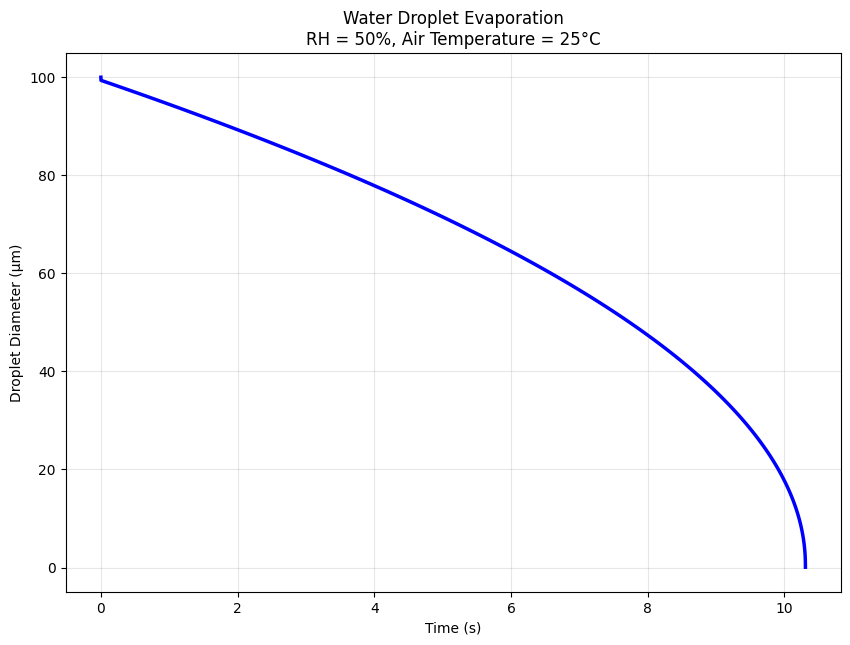


Final diameter: nan µm
Final temperature: nan K


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ====================== PHYSICAL FUNCTIONS ======================
pi = np.pi
Mw = 18.01528e-3
Ma = 28.97e-3
Patm = 101325.0
rho_w = 997.0
Cp_w = 4182.0

def psat(T):
    Tc = T - 273.15
    return 610.94 * np.exp(17.625 * Tc / (Tc + 243.04))

def latent_heat(T):
    Tc = T - 273.15
    return (2500.8 - 2.36 * Tc) * 1000

def air_density(T):
    return Patm / (287.05 * T)

def air_viscosity(T):
    C = 110.4
    mu0 = 1.716e-5
    T0 = 273.15
    return mu0 * (T/T0)**1.5 * (T0 + C) / (T + C)

def vapor_diffusivity(T):
    return 2.26e-5 * (T / 273.15)**1.81

def mass_coeff(Ta, d):
    rho = air_density(Ta)
    mu = air_viscosity(Ta)
    D = vapor_diffusivity(Ta)
    Sc = mu / (rho * D)
    Sh = 2 + 0.6 * Sc**(1/3)          # Simplified for u=0
    return Sh * D / d

def heat_coeff(Ta, d):
    k = 0.0241 * (Ta / 273.15)**0.9
    Nu = 2.0                          # Simplified
    return Nu * k / d

def derivatives(state, Ta, RH):
    d, Tp = state
    d = max(d, 1e-12)
    
    # Mass rate
    rho = air_density(Ta)
    km = mass_coeff(Ta, d)
    Ys = (Mw * psat(Tp)) / (Mw * psat(Tp) + Ma * (Patm - psat(Tp)))
    Yinf = (Mw * RH * psat(Ta)) / (Mw * RH * psat(Ta) + Ma * (Patm - RH*psat(Ta)))
    BM = (Ys - Yinf) / (1 - Ys + 1e-12)
    mdot = np.pi * d * rho * km * np.log(1 + max(BM, 1e-12))
    
    dd = -2 * mdot / (rho_w * pi * d**2)
    
    # Heat rate
    q = heat_coeff(Ta, d) * pi * d**2 * (Ta - Tp)
    Lv = latent_heat(Tp)
    dT = (q - mdot * Lv) / (rho_w * pi * d**3 / 6 * Cp_w)
    
    return np.array([dd, dT])

# ====================== SIMPLE INTEGRATOR ======================
def simulate(d0=100e-6, Tp0=298.15, Ta=298.15, RH=0.5, t_max=5.0):
    y = np.array([d0, Tp0])
    t = 0.0
    dt = 1e-5                    # Initial time step
    
    times = [t]
    diameters = [d0 * 1e6]
    temps = [Tp0]
    
    print("Simulation running...")
    
    while t < t_max and y[0] > 1e-9:
        dydt = derivatives(y, Ta, RH)
        
        # Adaptive time step
        scale = 0.01 / (np.abs(dydt[0]) * 1e6 + 1e-8)   # Control diameter change
        dt = min(dt * 1.1, scale, 0.05)
        
        y = y + dydt * dt
        t += dt
        
        times.append(t)
        diameters.append(y[0] * 1e6)
        temps.append(y[1])
        
        if len(times) % 10000 == 0:
            print(f"t = {t:.3f} s | Diameter = {y[0]*1e6:.2f} µm")
    
    print(f"Simulation finished at t = {t:.3f} s")
    return np.array(times), np.array(diameters), np.array(temps)

# ====================== RUN ======================
t, d, Tp = simulate(t_max=15.0)

# Plot
plt.figure(figsize=(10, 7))
plt.plot(t, d, 'b-', linewidth=2.5)
plt.xlabel("Time (s)")
plt.ylabel("Droplet Diameter (µm)")
plt.title("Water Droplet Evaporation\nRH = 50%, Air Temperature = 25°C")
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFinal diameter: {d[-1]:.2f} µm")
print(f"Final temperature: {Tp[-1]:.2f} K")

Running Smolik case...
Simulation finished. Final time = 8.8 s
Running Ranz-Marshall case...
Simulation finished. Final time = 7.3 s


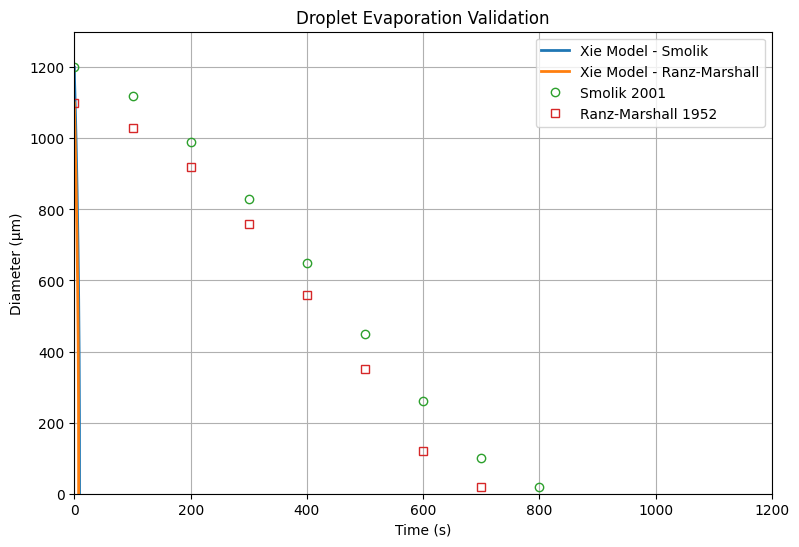

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp  

# ====================== PHYSICAL CONSTANTS ======================
pi = np.pi
g = 9.81
Mw = 18.01528e-3
Ma = 28.97e-3
Patm = 101325.0
rho_w = 997.0
Cp_w = 4182.0

# ====================== FUNCTIONS ======================
def air_density(T):
    return Patm / (287.05 * T)

def air_viscosity(T):
    C = 110.4
    mu0 = 1.716e-5
    T0 = 273.15
    return mu0 * (T/T0)**1.5 * (T0 + C) / (T + C)

def air_conductivity(T):
    return 0.0241 * (T / 273.15)**0.9

def air_cp(T):
    return 1006.0

def vapor_diffusivity(T):
    return 2.26e-5 * (T / 273.15)**1.81

def prandtl(T):
    mu = air_viscosity(T)
    cp = air_cp(T)
    k = air_conductivity(T)
    return cp * mu / k

def schmidt(T):
    mu = air_viscosity(T)
    rho = air_density(T)
    D = vapor_diffusivity(T)
    return mu / (rho * D)

def psat(T):
    Tc = np.clip(T - 273.15, -40, 80)
    return 610.94 * np.exp(17.625 * Tc / (Tc + 243.04))

def latent_heat(T):
    return max(2.0e6, (2500.8 - 2.36 * (T - 273.15)) * 1000)

def reynolds(rho, u, d, mu):
    d = max(abs(d), 1e-12)
    return abs(rho * u * d / mu)

def nusselt(Re, Pr):
    Re = max(Re, 0)
    Pr = max(Pr, 0)
    return 2 + 0.6 * np.sqrt(Re) * Pr**(1/3)

def sherwood(Re, Sc):
    Re = max(Re, 0)
    Sc = max(Sc, 0)
    return 2 + 0.6 * np.sqrt(Re) * Sc**(1/3)

def drag_coefficient(Re):
    if Re < 0.1:
        return 24 / Re
    elif Re < 1000:
        return 24 / Re * (1 + 0.15 * Re**0.687)
    else:
        return 0.44

def vapor_fraction_surface(Tp):
    Pv = psat(Tp)
    return (Mw * Pv) / (Mw * Pv + Ma * (Patm - Pv) + 1e-12)

def vapor_fraction_inf(Ta, RH):
    Pv = RH * psat(Ta)
    return (Mw * Pv) / (Mw * Pv + Ma * (Patm - Pv) + 1e-12)

def mass_spalding_number(Tp, Ta, RH):
    Ys = vapor_fraction_surface(Tp)
    Yinf = vapor_fraction_inf(Ta, RH)
    return (Ys - Yinf) / (1 - Ys + 1e-12)

def film_temperature(Tp, Ta):
    return 0.5 * (Tp + Ta)

def stefan_correction(B):
    if B < 1e-12:
        return 1.0
    return B / np.log(1 + B)

def corrected_sh(Tp, Ta, u, d, RH):
    Tf = film_temperature(Tp, Ta)
    Re = reynolds(air_density(Tf), u, d, air_viscosity(Tf))
    Sc = schmidt(Tf)
    Sh0 = 2 + 0.6 * np.sqrt(Re) * Sc**(1/3)
    BM = mass_spalding_number(Tp, Ta, RH)
    return Sh0 * stefan_correction(BM)

def corrected_nu(Tp, Ta, u, d, RH):
    Tf = film_temperature(Tp, Ta)
    Re = reynolds(air_density(Tf), u, d, air_viscosity(Tf))
    Pr = prandtl(Tf)
    Nu0 = 2 + 0.6 * np.sqrt(Re) * Pr**(1/3)
    BT = mass_spalding_number(Tp, Ta, RH) * (latent_heat(Tp) / (air_cp(Ta) * (Ta - Tp + 1e-12)))
    return Nu0 * stefan_correction(BT)

def mass_rate(d, Tp, Ta, u, RH):
    if d < 1e-8: return 0.0
    Tf = film_temperature(Tp, Ta)
    rho = air_density(Tf)
    D = vapor_diffusivity(Tf)
    Sh = corrected_sh(Tp, Ta, u, d, RH)
    BM = mass_spalding_number(Tp, Ta, RH)
    return np.pi * d * rho * (Sh * D / d) * np.log(1 + BM)

def heat_rate(d, Tp, Ta, u, RH):
    if d < 1e-8: return 0.0
    Tf = film_temperature(Tp, Ta)
    k = air_conductivity(Tf)
    Nu = corrected_nu(Tp, Ta, u, d, RH)
    h = Nu * k / d
    return h * np.pi * d**2 * (Ta - Tp)

def ddiameter_dt(d, Tp, Ta, u, RH):
    if d < 1e-8: return 0.0
    mdot = mass_rate(d, Tp, Ta, u, RH)
    return -2 * mdot / (rho_w * pi * d**2)

def dtemperature_dt(d, Tp, Ta, u, RH):
    if d < 1e-8: return 0.0
    m = rho_w * pi * d**3 / 6
    q = heat_rate(d, Tp, Ta, u, RH)
    mdot = mass_rate(d, Tp, Ta, u, RH)
    return (q - mdot * latent_heat(Tp)) / (m * Cp_w)

def acceleration(d, u, Ta):
    d = max(d, 1e-9)
    rhoa = air_density(Ta)
    mua = air_viscosity(Ta)
    Re = max(reynolds(rhoa, abs(u), d, mua), 1e-6)
    Cd = drag_coefficient(Re)
    drag = (3 * Cd * rhoa * u * abs(u)) / (4 * rho_w * d)
    return -g - np.clip(drag, -1000, 1000)

def derivative_full(t, state, Ta, RH):
    d, Tp, u, y = state
    d = max(d, 1e-12)
    Tp = np.clip(Tp, 230, 350)
    return np.array([
        ddiameter_dt(d, Tp, Ta, u, RH),
        dtemperature_dt(d, Tp, Ta, u, RH),
        acceleration(d, u, Ta),
        u
    ])

# ====================== SIMULATION ======================
def simulate(d0, Tp0, y0, u0, Ta, RH, t_max=1200):
    state0 = [d0, Tp0, u0, y0]
    
    sol = solve_ivp(
        fun=lambda t, y: derivative_full(t, y, Ta, RH),
        t_span=[0, t_max],
        y0=state0,
        method='RK45',
        rtol=1e-6,
        atol=1e-9,
        max_step=1.0
    )
    
    print(f"Simulation finished. Final time = {sol.t[-1]:.1f} s")
    return sol.t, sol.y[0], sol.y[1], sol.y[2], sol.y[3]

# ====================== VALIDATION ======================
def run_validation():
    Ta = 298.15
    RH = 0.0
    
    print("Running Smolik case...")
    t1, d1, _, _, _ = simulate(1.2e-3, 287.0, 1.5, 0.0, Ta, RH, t_max=1200)
    
    print("Running Ranz-Marshall case...")
    t2, d2, _, _, _ = simulate(1.1e-3, 282.0, 1.0, 0.0, Ta, RH, t_max=1200)
    
    plt.figure(figsize=(9, 6))
    plt.plot(t1, d1*1e6, lw=2, label="Xie Model - Smolik")
    plt.plot(t2, d2*1e6, lw=2, label="Xie Model - Ranz-Marshall")
    
    # Experimental points
    t_smolik = np.array([0,100,200,300,400,500,600,700,800])
    d_smolik = np.array([1200,1120,990,830,650,450,260,100,20])
    t_rm = np.array([0,100,200,300,400,500,600,700])
    d_rm = np.array([1100,1030,920,760,560,350,120,20])
    
    plt.plot(t_smolik, d_smolik, 'o', markerfacecolor='none', label="Smolik 2001")
    plt.plot(t_rm, d_rm, 's', markerfacecolor='none', label="Ranz-Marshall 1952")
    
    plt.xlabel("Time (s)")
    plt.ylabel("Diameter (µm)")
    plt.xlim(0, 1200)
    plt.ylim(0, 1300)
    plt.grid(True)
    plt.legend()
    plt.title("Droplet Evaporation Validation")
    plt.show()

# ====================== RUN ======================
run_validation()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ====================== PHYSICAL CONSTANTS ======================
pi = np.pi
g = 9.81
Mw = 18.01528e-3
Ma = 28.97e-3
Patm = 101325.0
rho_w = 997.0
Cp_w = 4182.0

# ====================== HELPER FUNCTIONS ======================
def air_density(T):
    return Patm / (287.05 * T)

def air_viscosity(T):
    C = 110.4
    mu0 = 1.716e-5
    T0 = 273.15
    return mu0 * (T/T0)**1.5 * (T0 + C) / (T + C)

def air_conductivity(T):
    return 0.0241 * (T / 273.15)**0.9

def air_cp(T):
    return 1006.0

def vapor_diffusivity(T):
    return 2.26e-5 * (T / 273.15)**1.81

def prandtl(T):
    mu = air_viscosity(T)
    cp = air_cp(T)
    k = air_conductivity(T)
    return cp * mu / k

def schmidt(T):
    mu = air_viscosity(T)
    rho = air_density(T)
    D = vapor_diffusivity(T)
    return mu / (rho * D)

def psat(T):
    Tc = np.clip(T - 273.15, -40, 80)
    return 610.94 * np.exp(17.625 * Tc / (Tc + 243.04))

def latent_heat(T):
    return max(2.0e6, (2500.8 - 2.36 * (T - 273.15)) * 1000)

def reynolds(rho, u, d, mu):
    d = max(abs(d), 1e-12)
    return abs(rho * u * d / mu)

def nusselt(Re, Pr):
    Re = max(Re, 0)
    Pr = max(Pr, 0)
    return 2 + 0.6 * np.sqrt(Re) * Pr**(1/3)

def sherwood(Re, Sc):
    Re = max(Re, 0)
    Sc = max(Sc, 0)
    return 2 + 0.6 * np.sqrt(Re) * Sc**(1/3)

def drag_coefficient(Re):
    if Re < 0.1:
        return 24 / Re
    elif Re < 1000:
        return 24 / Re * (1 + 0.15 * Re**0.687)
    else:
        return 0.44

def vapor_fraction_surface(Tp):
    Pv = psat(Tp)
    return (Mw * Pv) / (Mw * Pv + Ma * (Patm - Pv) + 1e-12)

def vapor_fraction_inf(Ta, RH):
    Pv = RH * psat(Ta)
    return (Mw * Pv) / (Mw * Pv + Ma * (Patm - Pv) + 1e-12)

def spalding_mass(Tp, Ta, RH):
    Ys = vapor_fraction_surface(Tp)
    Yinf = vapor_fraction_inf(Ta, RH)
    return (Ys - Yinf) / (1 - Ys + 1e-12)

def film_temperature(Tp, Ta):
    return 0.5 * (Tp + Ta)

def stefan_correction(B):
    if B < 1e-12:
        return 1.0
    return B / np.log(1 + B)

def corrected_sh(Tp, Ta, u, d, RH):
    Tf = film_temperature(Tp, Ta)
    Re = reynolds(air_density(Tf), u, d, air_viscosity(Tf))
    Sc = schmidt(Tf)
    Sh0 = 2 + 0.6 * np.sqrt(Re) * Sc**(1/3)
    BM = spalding_mass(Tp, Ta, RH)
    return Sh0 * stefan_correction(BM)

def corrected_nu(Tp, Ta, u, d, RH):
    Tf = film_temperature(Tp, Ta)
    Re = reynolds(air_density(Tf), u, d, air_viscosity(Tf))
    Pr = prandtl(Tf)
    Nu0 = 2 + 0.6 * np.sqrt(Re) * Pr**(1/3)
    BT = spalding_mass(Tp, Ta, RH) * (latent_heat(Tp) / (air_cp(Ta) * (Ta - Tp + 1e-12)))
    return Nu0 * stefan_correction(BT)

# ====================== RATES ======================
def mass_rate(d, Tp, Ta, u, RH):
    if d < 1e-8: return 0.0
    Tf = film_temperature(Tp, Ta)
    rho = air_density(Tf)
    D = vapor_diffusivity(Tf)
    Sh = corrected_sh(Tp, Ta, u, d, RH)
    BM = spalding_mass(Tp, Ta, RH)
    km = Sh * D / d
    return np.pi * d * rho * km * np.log(1 + BM)

def heat_rate(d, Tp, Ta, u, RH):
    if d < 1e-8: return 0.0
    Tf = film_temperature(Tp, Ta)
    k = air_conductivity(Tf)
    Nu = corrected_nu(Tp, Ta, u, d, RH)
    h = Nu * k / d
    return h * np.pi * d**2 * (Ta - Tp)

def ddiameter_dt(d, Tp, Ta, u, RH):
    if d < 1e-8: return 0.0
    mdot = mass_rate(d, Tp, Ta, u, RH)
    return -2 * mdot / (rho_w * pi * d**2)

def dtemperature_dt(d, Tp, Ta, u, RH):
    if d < 1e-8: return 0.0
    m = rho_w * pi * d**3 / 6
    q = heat_rate(d, Tp, Ta, u, RH)
    mdot = mass_rate(d, Tp, Ta, u, RH)
    return (q - mdot * latent_heat(Tp)) / (m * Cp_w)

def acceleration(d, u, Ta):
    d = max(d, 1e-9)
    rhoa = air_density(Ta)
    mua = air_viscosity(Ta)
    Re = max(reynolds(rhoa, abs(u), d, mua), 1e-6)
    Cd = drag_coefficient(Re)
    drag = (3 * Cd * rhoa * u * abs(u)) / (4 * rho_w * d)
    return -g - np.clip(drag, -1000, 1000)

def derivative_full(t, state, Ta, RH):
    d, Tp, u, y = state
    d = max(d, 1e-12)
    Tp = np.clip(Tp, 230, 350)
    return np.array([
        ddiameter_dt(d, Tp, Ta, u, RH),
        dtemperature_dt(d, Tp, Ta, u, RH),
        acceleration(d, u, Ta),
        u
    ])

# ====================== SIMULATION ======================
def droplet_simulation(d0, RH, height=1.8, Ta=295.15, t_max=120):
    Tp0 = Ta
    u0 = 0.0
    state0 = [d0, Tp0, u0, height]
    
    sol = solve_ivp(
        fun=lambda t, y: derivative_full(t, y, Ta, RH),
        t_span=[0, t_max],
        y0=state0,
        method='LSODA',
        rtol=1e-6,
        atol=1e-9,
        max_step=1.0
    )
    
    t = sol.t
    d = sol.y[0]
    Tp = sol.y[1]
    u = sol.y[2]
    z = sol.y[3]
    
    return t, d, z, Tp

# ====================== PLOTS ======================
def plot_small_droplets():
    cases = {}
    for d0 in [50e-6, 100e-6]:
        for RH in [0.5, 1.0]:
            key = f"{int(d0*1e6)}μm_{int(RH*100)}%RH"
            cases[key] = droplet_simulation(d0, RH)
    
    plt.figure(figsize=(8, 6))
    for key, data in cases.items():
        t, d, z, T = data
        plt.plot(t, d*1e6, lw=2, label=key)
    
    plt.xlabel("Time (s)")
    plt.ylabel("Diameter (µm)")
    plt.grid(True)
    plt.legend(fontsize=9)
    plt.title("Small Droplet Evaporation")
    plt.show()

def plot_validation():
    Ta = 298.15
    RH = 0.0
    t1, d1, _, _ = droplet_simulation(1.2e-3, RH, Ta=Ta)
    t2, d2, _, _ = droplet_simulation(1.1e-3, RH, Ta=Ta)
    
    plt.figure(figsize=(9, 6))
    plt.plot(t1, d1*1e6, 'b-', lw=2, label="this study (Smolik)")
    plt.plot(t2, d2*1e6, 'r-', lw=2, label="this study (RM)")
    
    # Experimental data
    t_s = np.array([0,100,200,300,400,500,600,700,800])
    d_s = np.array([1200,1120,990,830,650,450,260,100,20])
    t_r = np.array([0,100,200,300,400,500,600,700])
    d_r = np.array([1100,1030,920,760,560,350,120,20])
    
    plt.plot(t_s, d_s, 'o', color='blue', markerfacecolor='none', label="exp. Smolik01")
    plt.plot(t_r, d_r, 's', color='red', markerfacecolor='none', label="exp. RM1952")
    
    plt.xlabel("Time (s)")
    plt.ylabel("Diameter (µm)")
    plt.xlim(0, 1200)
    plt.ylim(0, 1300)
    plt.grid(True)
    plt.legend()
    plt.title("Droplet Evaporation Validation")
    plt.show()

# ====================== RUN ======================
plot_small_droplets()
plot_validation()